**<h3 style="color:orange">Please make sure any LLM coding assistant like Github Copilot or Cursus is turned OFF!</h2>**

**<h4 style="color:orange">We want you to learn and think critically, not to let LLMs do your work for you.</h4>**

**<h4 style="color:orange">Ask your group members or the internet for help, BEFORE asking your favorite chatbot.</h4>**

<img src="../figures/copilot.png">

# Assignment 1 Part 2: Modelling Boids as a Lagrangian System


In [1]:
# Import all the required libraries here
import torch as T
from torch import nn
from torch.utils.data import Dataset, Subset
from torch_geometric.data import Data, DataLoader as GraphDataLoader
import lightning as L
import os
import pickle
import matplotlib.pyplot as plt


print(f"Success! Running PyTorch {T.__version__} and Lightning {L.__version__}")
cuda_available = T.cuda.is_available()
if cuda_available:
    print(f"CUDA is available! Device count: {T.cuda.device_count()}")
else:
    print("CUDA is not available.")

Success! Running PyTorch 2.7.1+cu118 and Lightning 2.6.6
CUDA is available! Device count: 1


In [2]:
class BoidsDataset(Dataset):
    """Dataset for the Boids simulation data."""

    def __init__(self, path):
        self.path = path
        self.nodes = T.tensor([], dtype=T.float32)  
        self.edge_index = T.tensor([], dtype=T.long)
        self.edge_attributes = T.tensor([], dtype=T.float32) 
        self.n_simulations = 0
        self.traj_length = 0

    def load_data(self):
        if not os.path.exists(self.path):
            raise FileNotFoundError(
                f"Data file not found at {self.path}. Please check the path and try again."
            )
        with open(self.path, "rb") as f:
            data = pickle.load(f)

        # DONE: Implement the logic to load nodes and edges from the data dictionary 

        positions = T.stack([T.tensor(sim, dtype=T.float32) for sim in data])
        velocities = T.diff(positions, dim=1)
        positions = positions[:, 1:]
        next_velocities = T.cat([velocities[:, 1:], velocities[:, -1:]], dim=1)
        self.nodes = T.cat([positions, velocities, velocities.norm(dim=-1, keepdim=True), next_velocities], dim=-1)

        RADIUS = 2.0
        edge_index = []
        edge_attributes = []
        for sim in positions:
            sim_edges = []
            sim_attributes = []
            for frame in sim:
                sq_dists = T.cdist(frame, frame) ** 2
                neighbours = (sq_dists < RADIUS ** 2).fill_diagonal_(False)
                edges = neighbours.nonzero().T
                sim_edges.append(edges)
                sim_attributes.append(sq_dists[edges[0], edges[1]].unsqueeze(-1))
            edge_index.append(sim_edges)
            edge_attributes.append(sim_attributes)
        self.edge_index = edge_index
        self.edge_attributes = edge_attributes

        self.n_simulations = self.nodes.shape[0]
        self.traj_length = self.nodes.shape[1] - 1

        # DONE

        print(
            f"\nLoaded data from {self.path}, containing {len(data)} samples of shape {data[0].shape}\n"
        )

class BoidsTrajectoryDataset(BoidsDataset):
    """One sample = one full trajectory: nodes has shape (traj_len, ...)."""

    def __len__(self):
        return self.n_simulations

    def __getitem__(self, idx):
        return Data(
            x=self.nodes[idx],
            edge_index=self.edge_index[idx],
            edge_attr=self.edge_attributes[idx]
        )


class BoidsStepDataset(BoidsDataset):
    """One sample = one timestep: nodes has shape (...)."""

    def __len__(self):
        return self.n_simulations * self.traj_length

    def __getitem__(self, idx):
        sim_idx, t_idx = idx // self.traj_length, idx % self.traj_length
        return Data(
            x=self.nodes[sim_idx][t_idx],
            edge_index=self.edge_index[sim_idx][t_idx],
            edge_attr=self.edge_attributes[sim_idx][t_idx]
        )

class DataModule(L.LightningDataModule):
    """Lightning DataModule class that manages the dataset splitting and the dataloaders"""

    def __init__(self, dataset, batch_size, train_split, val_split, seed=42):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.train_split = train_split
        self.val_split = val_split
        self.seed = seed

    def prepare_data(self):
        self.dataset.load_data()

    def setup(self, stage=None):
            if getattr(self, "train_set", None) is not None:
                return

            # DONE: Implement logic to split the dataset into train, validation, and test sets

            train_size = int(len(self.dataset) * self.train_split)
            val_size = int(len(self.dataset) * self.val_split)
            indices = list(range(len(self.dataset)))

            self.train_set = Subset(self.dataset, indices[:train_size])
            self.val_set = Subset(self.dataset, indices[train_size : train_size + val_size])
            self.test_set = Subset(self.dataset, indices[train_size + val_size :])


            #DONE

    def train_dataloader(self):
        return GraphDataLoader(self.train_set, batch_size=self.batch_size)

    def val_dataloader(self):
        return GraphDataLoader(self.val_set, batch_size=self.batch_size)

    def test_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

    def predict_dataloader(self):
        return GraphDataLoader(self.test_set, batch_size=self.batch_size)

path = os.path.join(os.getcwd(), "..", "data","boids_dataset.pkl")
boids_dataset = BoidsTrajectoryDataset(path=path)
boids_dataset.load_data()


Loaded data from c:\Users\20224785\OneDrive - TU Eindhoven\Documents\Master\y2q1\ML for science\Assignment 1\ml4sci-2026\assignments\..\data\boids_dataset.pkl, containing 2000 samples of shape (50, 100, 3)



positions range 0.5684 to 24.4844
speed mean 1.4922 std 0.0199
acceleration mean 0.3591 = 24% of |v|
isolated boids t=1 70% t=49 0%
speed near wall 1.4186 vs away 1.4935


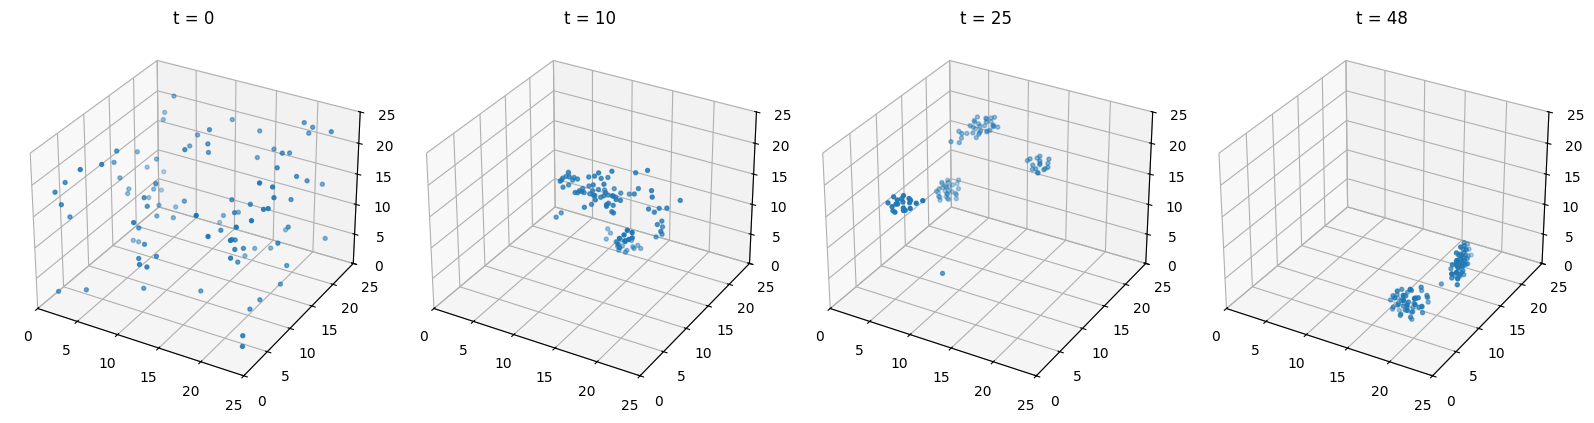

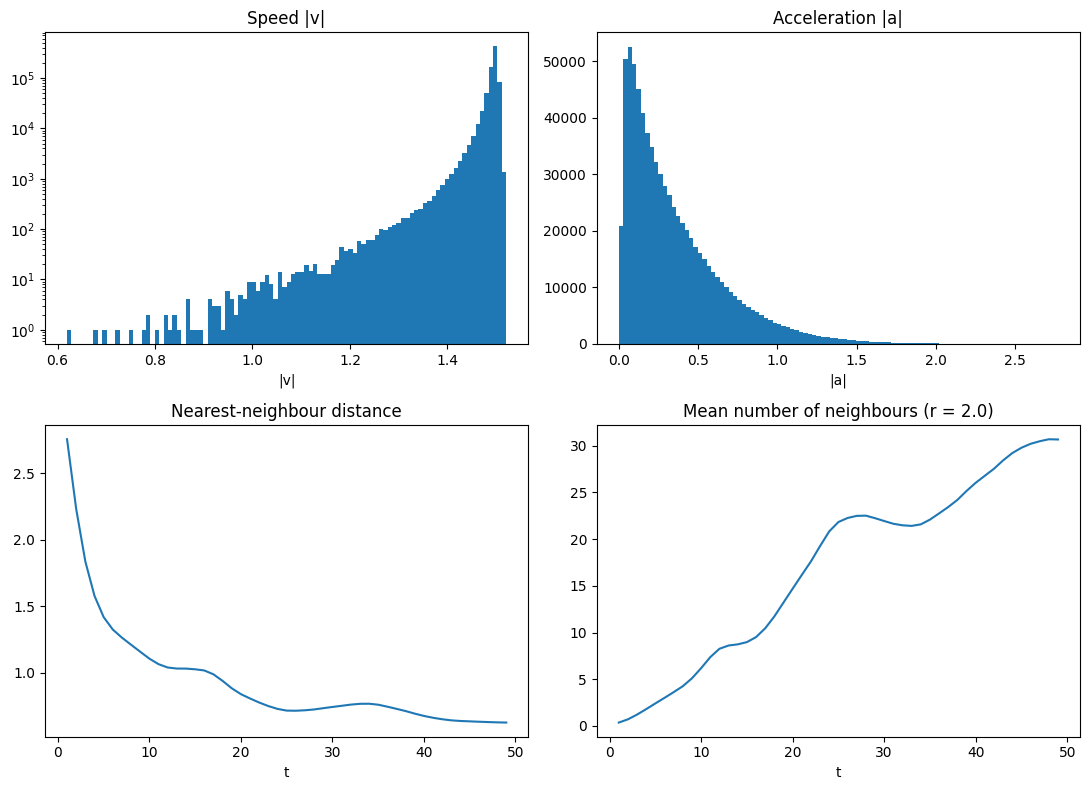

In [3]:
# Perform the exploratory data analysis here

sim = boids_dataset.nodes[0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': '3d'})
for ax, t in zip(axes, [0, 10, 25, 48]):
    ax.scatter(sim[t, :, 0], sim[t, :, 1], sim[t, :, 2], s=8)
    ax.set(title=f't = {t}', xlim=(0, 25), ylim=(0, 25), zlim=(0, 25))
plt.tight_layout()

X = boids_dataset.nodes[:int(0.8 * boids_dataset.n_simulations)][::10]
P = X[..., :3]
V = X[..., 3:6]
speed = V.norm(dim=-1)
acc = (X[:, :-1, :, 7:10] - X[:, :-1, :, 3:6]).norm(dim=-1)
wall_dist = T.minimum(P, 25 - P).min(-1).values
near_wall = wall_dist < 2

CUTOFF = 2.0
frames = range(1, P.shape[1] + 1)
nn_dist = []
degree = []
isolated = []
for t in range(P.shape[1]):
    D = T.cdist(P[:, t], P[:, t])
    D.diagonal(dim1=-2, dim2=-1)[:] = 1e9
    k = (D < CUTOFF).sum(-1).float()
    nn_dist.append(D.min(-1).values.mean())
    degree.append(k.mean())
    isolated.append(k.eq(0).float().mean() * 100)

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].hist(speed.flatten().numpy(), bins=100)
ax[0, 0].set(title='Speed |v|', xlabel='|v|', yscale='log')
ax[0, 1].hist(acc.flatten().numpy(), bins=100)
ax[0, 1].set(title='Acceleration |a|', xlabel='|a|')
ax[1, 0].plot(frames, nn_dist)
ax[1, 0].set(title='Nearest-neighbour distance', xlabel='t')
ax[1, 1].plot(frames, degree)
ax[1, 1].set(title=f'Mean number of neighbours (r = {CUTOFF})', xlabel='t')
plt.tight_layout()

print(f"positions range {P.min():.4f} to {P.max():.4f}")
print(f"speed mean {speed.mean():.4f} std {speed.std():.4f}")
print(f"acceleration mean {acc.mean():.4f} = {100 * acc.mean() / speed.mean():.0f}% of |v|")
print(f"isolated boids t=1 {isolated[0]:.0f}% t=49 {isolated[-1]:.0f}%")
print(f"speed near wall {speed[near_wall].mean():.4f} vs away {speed[~near_wall].mean():.4f}")


In [7]:
class EGNNLayer(nn.Module):
    
    def __init__(self, node_dim, edge_dim, hidden_dim, C=1.0):
        super().__init__()
        self.C = C
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + 1 + edge_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        self.velocity_mlp = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1, bias=False),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, node_dim),
        )
        nn.init.xavier_uniform_(self.coord_mlp[-1].weight, gain=0.001)
        nn.init.zeros_(self.velocity_mlp[-1].weight)
        nn.init.ones_(self.velocity_mlp[-1].bias)

    def forward(self, h, x, v, edge_index, edge_attr):
        src, dst = edge_index
        rel = x[src] - x[dst]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)
        m = self.edge_mlp(T.cat([h[src], h[dst], dist2, edge_attr], dim=-1))
        agg = h.new_zeros(h.shape[0], m.shape[-1])
        agg.index_add_(0, dst, m)
        h_new = self.node_mlp(T.cat([h, agg], dim=-1))
        interaction = v.new_zeros(v.shape)
        interaction.index_add_(0, dst, rel * self.coord_mlp(m))
        v_new = self.velocity_mlp(h) * v + self.C * interaction
        x_new = x + v_new
        return h_new, x_new, v_new


class EGNN(nn.Module):

    def __init__(self, input_dim=1, hidden_dim=64, edge_dim=1, n_layers=4):
        super().__init__()
        self.node_in = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            EGNNLayer(node_dim=hidden_dim, edge_dim=edge_dim, hidden_dim=hidden_dim)
            for _ in range(n_layers)
        ])

    def forward(self, x, edge_index, edge_attr):
        positions = x[..., :3]
        velocities = x[..., 3:6]
        h = self.node_in(x[..., 6:7])
        for layer in self.layers:
            h, positions, velocities = layer(h, positions, velocities, edge_index, edge_attr)
        return velocities


In [5]:
class BoidsModel(L.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):

        # TODO Implement the logic for a single training/validation step here
        
        return batch

    def training_step(self, batch):
        loss = self._step(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch):
        loss = self._step(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch):

        # TODO Implement the logic for autoregressive rollout here

        return batch

    def configure_optimizers(self):
        return T.optim.Adam(self.parameters(), lr=self.learning_rate)

class LossHistory(L.Callback):
    def __init__(self):
        self.train_loss, self.val_loss = [], []
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get("train_loss").item())
    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(trainer.callback_metrics.get("val_loss").item())

In [6]:
# Initialize dataset
dataset = BoidsStepDataset(path)

# Initialize datamodule
datamodule = DataModule(dataset)

# Initialize model
egnn = EGNN()
model = BoidsModel(egnn)

# Initialize trainer
loss_history = LossHistory()
trainer = L.Trainer(callbacks=[loss_history])

# Fit the model to the dataset
trainer.fit(model, datamodule=datamodule)

# Load the inference dataset 
traj_dataset = BoidsTrajectoryDataset(path)
datamodule = DataModule(traj_dataset)

# Perform inference
rollouts = trainer.predict(model, datamodule=datamodule)

TypeError: DataModule.__init__() missing 3 required positional arguments: 'batch_size', 'train_split', and 'val_split'

In [ ]:
# Evaluate the model and make plots here